# 14,500 años. Esa fue la fecha que ancló la llegada de los humanos a Sudamérica. Nadie la revisó en 50 años.

Cuando un equipo independiente por fin lo hizo, las dataciones no cuadraban.

---

**Paper:** Fiedel, Mariman-Lincoñir et al. (2025) — *Monte Verde is not an early archaeological site* · Science  
**DOI:** [10.1126/science.adw9217](https://doi.org/10.1126/science.adw9217)  
**Video:** [Ver en YouTube](https://youtube.com/watch?v=04c87eYoTV4)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-27-monte-verde-fecha-mal/notebook.ipynb)

## El sitio que anclaba todo

Monte Verde II, en el sur de Chile, fue excavado a finales de los 70. Los artefactos que encontraron estaban datados en ~14,500 años antes del presente (B.P.) — anterior a la cultura Clovis de Norteamérica. Eso lo convirtió en la evidencia más sólida de que los humanos llegaron a Sudamérica antes de lo que se pensaba.

Durante casi 50 años, nadie hizo una investigación independiente del sitio. En 2025, un nuevo equipo tomó muestras de los mismos estratos y usó dos métodos de datación: **radiocarbono (¹⁴C)** y **luminiscencia (IR50)**. Además, identificaron una **tefra** (ceniza volcánica) datada en ~11,000 B.P. que estaba *debajo* de la capa arqueológica.

¿Qué implica eso? Veamos los datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FECHA_ORIGINAL = 14_500       # Fecha original de Monte Verde II (años B.P.)
TEFRA_FECHA = 11_000          # Fecha de la tefra volcánica (años B.P.)
HOLOCENO_MEDIO = (8200, 4200) # Rango del Holoceno Medio (años B.P.)
FUENTE = 'Fuente: Fiedel, Mariman-Lincoñir et al. (2025), Science | Datos: Tables 1-2 del paper'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_TEFRA = '#059669'
COLOR_HOLOCENO = '#7C3AED'

# ── Imports + estilo ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, urllib.request

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# ── Cargar datos ──────────────────────────────────────────────
BASE_URL = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
PAPER = f'{BASE_URL}/papers/2026-03-27-monte-verde-fecha-mal/datos'

for fname in ['dataciones_c14.csv', 'dataciones_luminiscencia.csv']:
    local = f'datos/{fname}'
    if not os.path.exists(local):
        os.makedirs('datos', exist_ok=True)
        urllib.request.urlretrieve(f'{PAPER}/{fname}', local)

c14 = pd.read_csv('datos/dataciones_c14.csv')
lum = pd.read_csv('datos/dataciones_luminiscencia.csv')

c14_valid_count = c14.cal_age_median_bp.notna().sum()
print(f'Dataciones ¹⁴C: {len(c14)} muestras totales ({c14_valid_count} con edad calibrada), {c14.stratum.nunique()} estratos')
print(f'Dataciones luminiscencia: {len(lum)} muestras, {lum.section.nunique()} secciones')
print(f'Estratos: {", ".join(c14.stratum.unique())}')
print(f'Rango ¹⁴C calibrado: {c14.cal_age_median_bp.min():.0f} – {c14.cal_age_median_bp.max():.0f} años B.P.')

Dataciones ¹⁴C: 23 muestras totales (22 con edad calibrada), 5 estratos
Dataciones luminiscencia: 6 muestras, 3 secciones
Estratos: SU1a, SU1b, SU2, SU1c, SU1d
Rango ¹⁴C calibrado: 3270 – 16450 años B.P.


## Todas las dataciones, capa por capa

Aquí están.

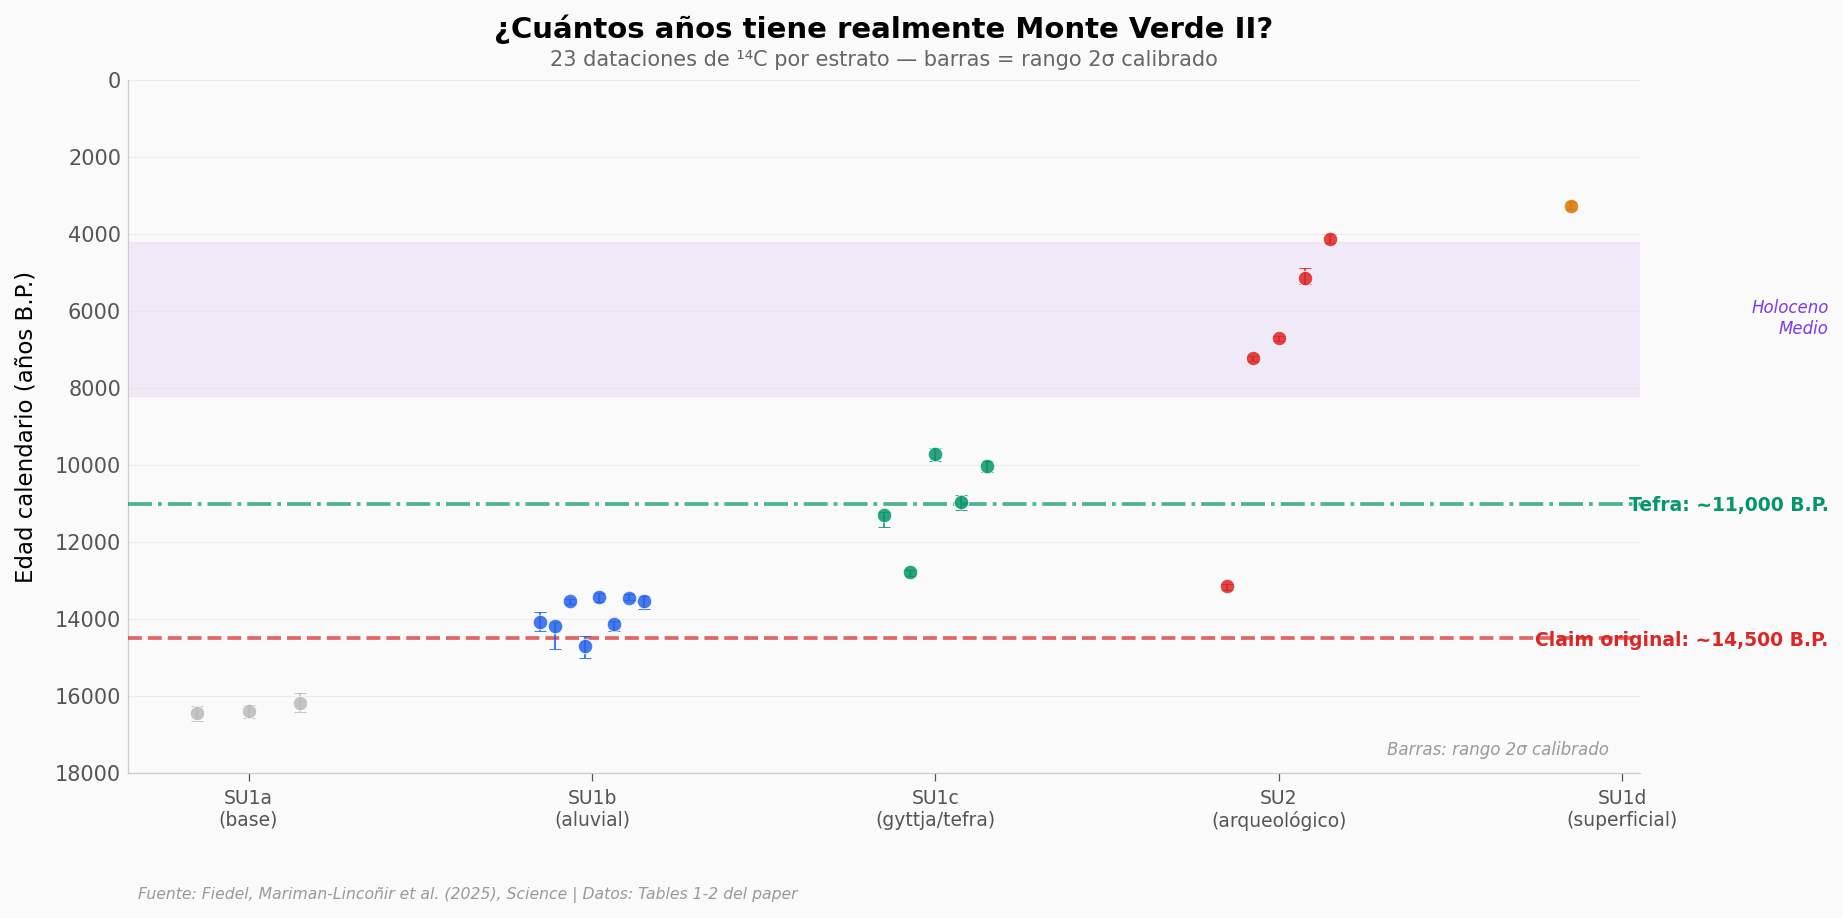

In [2]:
# ── Gráfica hero: dataciones por estrato ──────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

# Orden estratigráfico (de más profundo a más superficial)
strata_order = ['SU1a', 'SU1b', 'SU1c', 'SU2', 'SU1d']
strata_labels = ['SU1a\n(base)', 'SU1b\n(aluvial)', 'SU1c\n(gyttja/tefra)',
                 'SU2\n(arqueológico)', 'SU1d\n(superficial)']
strata_colors = ['#BBBBBB', '#2563EB', COLOR_TEFRA, COLOR_ALERTA, '#D97706']

np.random.seed(42)
for i, (stratum, label, color) in enumerate(zip(strata_order, strata_labels, strata_colors)):
    sub = c14[c14.stratum == stratum].dropna(subset=['cal_age_median_bp'])
    n = len(sub)
    if n == 0:
        continue

    # Jitter reproducible
    x_pos = np.linspace(i - 0.15, i + 0.15, n)
    np.random.shuffle(x_pos)

    # Puntos con barras de error (2σ)
    for j, (_, row) in enumerate(sub.iterrows()):
        yerr_low = row.cal_age_median_bp - row.cal_age_2sigma_min_bp
        yerr_high = row.cal_age_2sigma_max_bp - row.cal_age_median_bp
        ax.errorbar(x_pos[j], row.cal_age_median_bp,
                    yerr=[[yerr_low], [yerr_high]],
                    fmt='o', color=color, markersize=7,
                    ecolor=color, elinewidth=1, capsize=3, capthick=1,
                    markeredgecolor='white', markeredgewidth=0.5, alpha=0.85, zorder=5)

# Línea de referencia: claim original
ax.axhline(y=FECHA_ORIGINAL, color=COLOR_ALERTA, linewidth=1.8, linestyle='--', alpha=0.7, zorder=3)
ax.text(4.6, FECHA_ORIGINAL + 200, f'Claim original: ~{FECHA_ORIGINAL:,} B.P.',
        fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='right')

# Línea de tefra
ax.axhline(y=TEFRA_FECHA, color=COLOR_TEFRA, linewidth=1.8, linestyle='-.', alpha=0.7, zorder=3)
ax.text(4.6, TEFRA_FECHA + 200, f'Tefra: ~{TEFRA_FECHA:,} B.P.',
        fontsize=9, color=COLOR_TEFRA, fontweight='bold', ha='right')

# Banda del Holoceno Medio
ax.axhspan(HOLOCENO_MEDIO[1], HOLOCENO_MEDIO[0], color=COLOR_HOLOCENO, alpha=0.08, zorder=1)
ax.text(4.6, (HOLOCENO_MEDIO[0] + HOLOCENO_MEDIO[1]) / 2, 'Holoceno\nMedio',
        fontsize=8, color=COLOR_HOLOCENO, ha='right', va='center', fontstyle='italic')

ax.set_xticks(range(len(strata_order)))
ax.set_xticklabels(strata_labels, fontsize=9)
ax.set_ylabel('Edad calendario (años B.P.)', fontsize=11)
ax.set_title('¿Cuántos años tiene realmente Monte Verde II?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '23 dataciones de ¹⁴C por estrato — barras = rango 2σ calibrado',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.invert_yaxis()
ax.set_ylim(18000, 0)

ax.text(0.98, 0.02, 'Barras: rango 2σ calibrado', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
os.makedirs('figuras', exist_ok=True)
plt.savefig('figuras/dataciones_por_estrato.png', dpi=200, bbox_inches='tight')
plt.show()

Cada punto es una muestra datada con radiocarbono (¹⁴C). Las barras verticales muestran el rango de incertidumbre calibrado (2σ).

- Los **estratos SU1a y SU1b** (los más profundos) tienen edades de 13,000-16,500 años B.P. — consistentes con depósitos aluviales del Pleistoceno tardío.
- El **estrato SU1c** contiene la tefra volcánica datada en ~11,000 B.P. (línea verde). Todo lo que está *encima* de esta tefra tiene que ser más joven.
- El **estrato SU2** — donde se reportaron los artefactos arqueológicos — tiene la mayoría de sus dataciones entre 4,000-7,200 B.P. Una fecha aislada de ~13,000 B.P. los autores la interpretan como material retrabajado (madera antigua redepositada).
- La línea roja punteada marca la fecha original: ~14,500 B.P. Ninguna muestra del estrato arqueológico llega ahí.

## La tefra que lo cambia todo

La pieza clave es la ceniza volcánica (tefra). Si una capa de ceniza de 11,000 años está *debajo* de los artefactos, los artefactos no pueden tener 14,500 años.

¿Pero qué tan jóvenes son exactamente las fechas del estrato arqueológico?

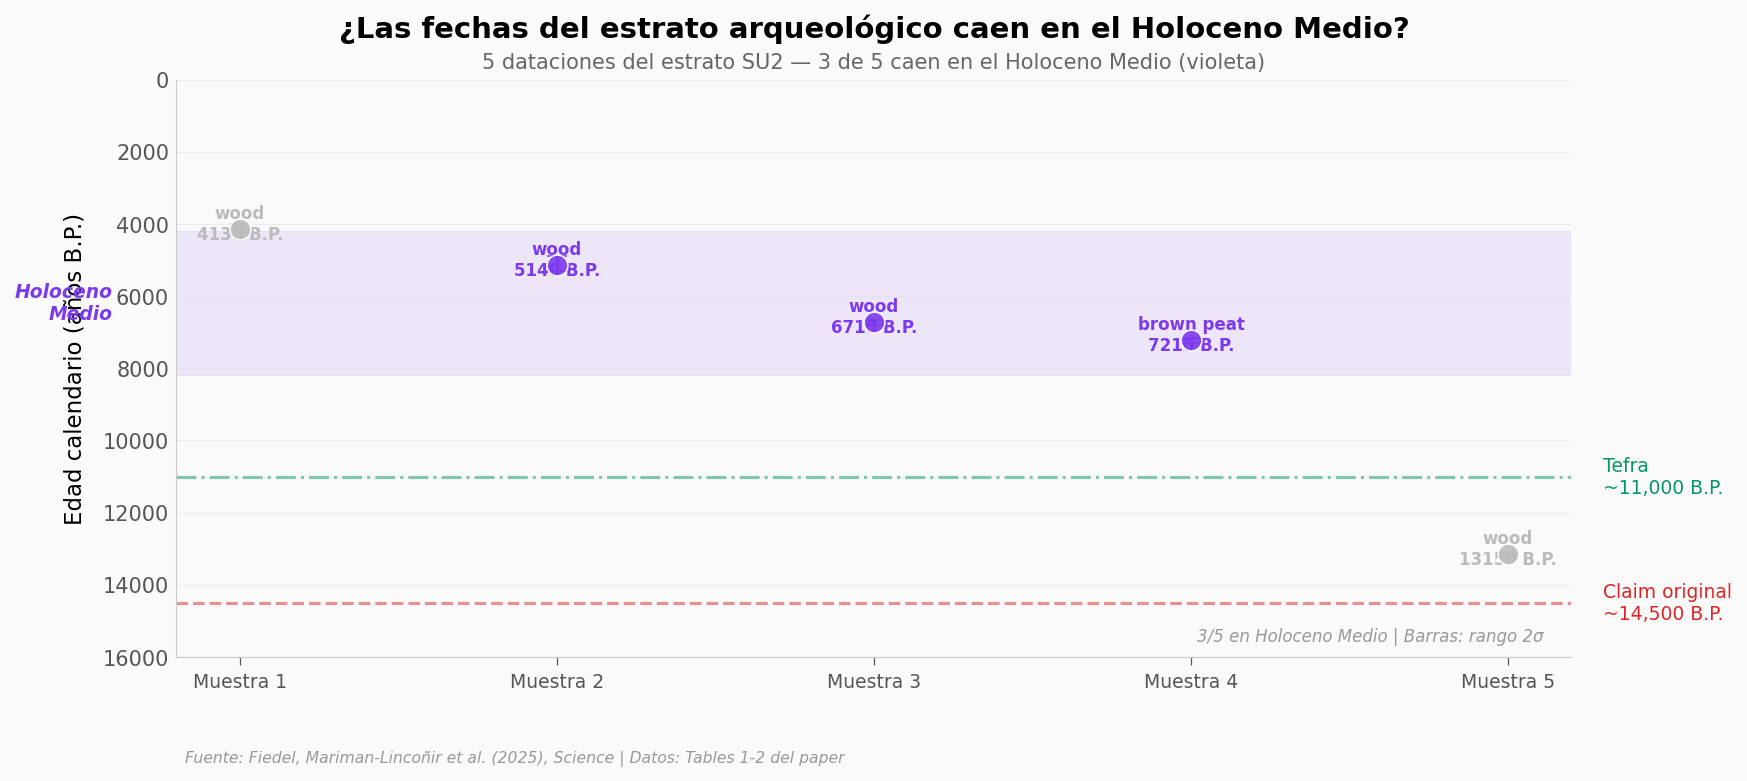

In [3]:
# ── Zoom: estrato SU2 vs Holoceno Medio ──────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

su2 = c14[c14.stratum == 'SU2'].dropna(subset=['cal_age_median_bp']).sort_values('cal_age_median_bp')

colors_su2 = []
for _, row in su2.iterrows():
    if HOLOCENO_MEDIO[1] <= row.cal_age_median_bp <= HOLOCENO_MEDIO[0]:
        colors_su2.append(COLOR_HOLOCENO)
    else:
        colors_su2.append('#BBBBBB')

# Banda del Holoceno Medio
ax.axhspan(HOLOCENO_MEDIO[1], HOLOCENO_MEDIO[0], color=COLOR_HOLOCENO, alpha=0.10, zorder=1)

for j, (_, row) in enumerate(su2.iterrows()):
    yerr_low = row.cal_age_median_bp - row.cal_age_2sigma_min_bp
    yerr_high = row.cal_age_2sigma_max_bp - row.cal_age_median_bp
    ax.errorbar(j, row.cal_age_median_bp,
                yerr=[[yerr_low], [yerr_high]],
                fmt='o', color=colors_su2[j], markersize=10,
                ecolor=colors_su2[j], elinewidth=1.5, capsize=5, capthick=1.5,
                markeredgecolor='white', markeredgewidth=0.8, alpha=0.9, zorder=5)
    # Label con material
    ax.text(j, row.cal_age_median_bp + 400, f'{row.material}\n{row.cal_age_median_bp:.0f} B.P.',
            fontsize=8, ha='center', va='bottom', color=colors_su2[j], fontweight='bold')

# Líneas de referencia
ax.axhline(y=FECHA_ORIGINAL, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.5)
ax.text(4.3, FECHA_ORIGINAL, f'Claim original\n~{FECHA_ORIGINAL:,} B.P.',
        fontsize=9, color=COLOR_ALERTA, ha='left', va='center')

ax.axhline(y=TEFRA_FECHA, color=COLOR_TEFRA, linewidth=1.5, linestyle='-.', alpha=0.5)
ax.text(4.3, TEFRA_FECHA, f'Tefra\n~{TEFRA_FECHA:,} B.P.',
        fontsize=9, color=COLOR_TEFRA, ha='left', va='center')

# Label Holoceno Medio
ax.text(-0.4, (HOLOCENO_MEDIO[0] + HOLOCENO_MEDIO[1]) / 2, 'Holoceno\nMedio',
        fontsize=9, color=COLOR_HOLOCENO, ha='right', va='center', fontstyle='italic', fontweight='bold')

ax.set_xticks(range(len(su2)))
ax.set_xticklabels([f'Muestra {i+1}' for i in range(len(su2))], fontsize=9)
ax.set_ylabel('Edad calendario (años B.P.)', fontsize=11)
ax.set_ylim(0, 16000)
ax.invert_yaxis()
ax.set_title('¿Las fechas del estrato arqueológico caen en el Holoceno Medio?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'5 dataciones del estrato SU2 — 3 de 5 caen en el Holoceno Medio (violeta)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

n_hol = sum(1 for c in colors_su2 if c == COLOR_HOLOCENO)
ax.text(0.98, 0.02, f'{n_hol}/5 en Holoceno Medio | Barras: rango 2σ',
        transform=ax.transAxes, fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/su2_holoceno_medio.png', dpi=200, bbox_inches='tight')
plt.show()

## Dos métodos, una dirección

El estudio no se apoyó solo en radiocarbono. También usaron **luminiscencia** (IR50) — un método completamente independiente que mide cuánto tiempo ha pasado desde que los granos minerales estuvieron expuestos a la luz por última vez.

¿Los dos métodos apuntan en la misma dirección?

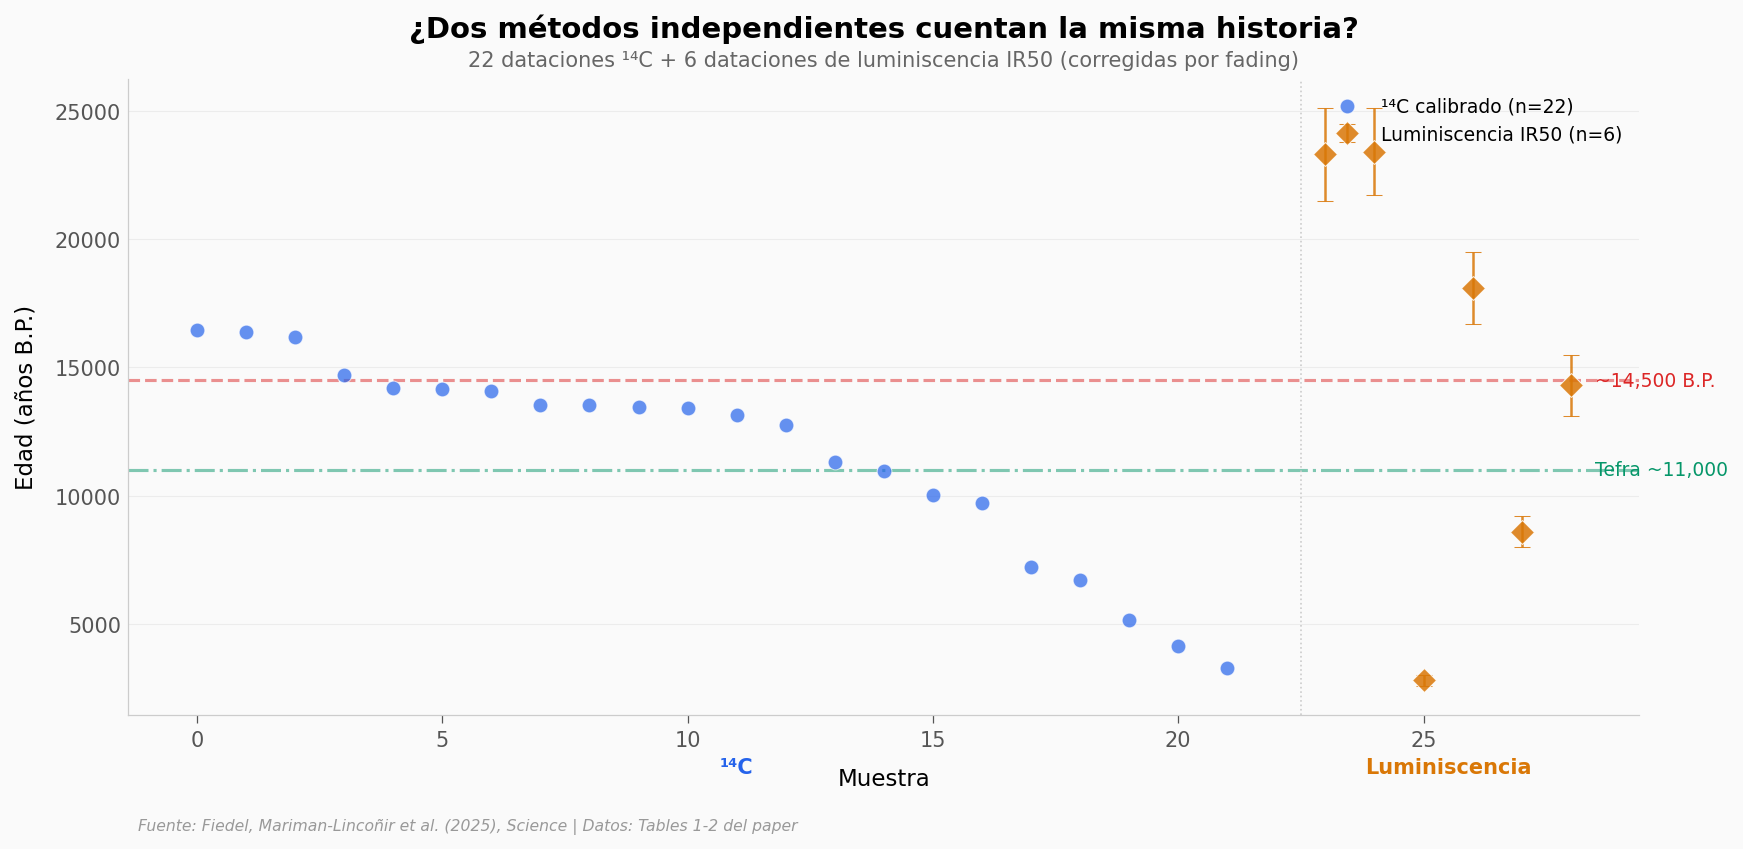

In [4]:
# ── Dataciones C14 vs Luminiscencia ───────────────────────────
fig, ax = plt.subplots(figsize=(13, 5.5))

# C14: edades calibradas
c14_valid = c14.dropna(subset=['cal_age_median_bp'])
ax.scatter(range(len(c14_valid)), c14_valid.cal_age_median_bp.values,
           color=COLOR_DATOS, s=50, alpha=0.7, edgecolors='white', linewidths=0.5,
           zorder=5, label=f'¹⁴C calibrado (n={len(c14_valid)})')

# Luminiscencia: convertir ka → años BP
lum_bp = lum.ir50_age_corrected_ka * 1000
lum_err_bp = lum.ir50_age_corrected_err_ka * 1000
x_lum = np.linspace(len(c14_valid) + 1, len(c14_valid) + len(lum), len(lum))
ax.errorbar(x_lum, lum_bp, yerr=lum_err_bp,
            fmt='D', color=COLOR_REFERENCIA, markersize=8,
            ecolor=COLOR_REFERENCIA, elinewidth=1.2, capsize=4, capthick=1.2,
            markeredgecolor='white', markeredgewidth=0.5, alpha=0.85,
            zorder=5, label=f'Luminiscencia IR50 (n={len(lum)})')

# Referencia
ax.axhline(y=FECHA_ORIGINAL, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.5)
ax.text(len(c14_valid) + len(lum) + 0.5, FECHA_ORIGINAL, f'~{FECHA_ORIGINAL:,} B.P.',
        fontsize=9, color=COLOR_ALERTA, va='center')

ax.axhline(y=TEFRA_FECHA, color=COLOR_TEFRA, linewidth=1.5, linestyle='-.', alpha=0.5)
ax.text(len(c14_valid) + len(lum) + 0.5, TEFRA_FECHA, f'Tefra ~{TEFRA_FECHA:,}',
        fontsize=9, color=COLOR_TEFRA, va='center')

# Separador visual
ax.axvline(x=len(c14_valid) + 0.5, color='#CCCCCC', linewidth=0.8, linestyle=':')
ax.text(len(c14_valid)/2, -800, '¹⁴C', fontsize=10, ha='center', color=COLOR_DATOS, fontweight='bold')
ax.text(len(c14_valid) + 0.5 + len(lum)/2, -800, 'Luminiscencia', fontsize=10, ha='center',
        color=COLOR_REFERENCIA, fontweight='bold')

ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.set_ylabel('Edad (años B.P.)', fontsize=11)
ax.set_xlabel('Muestra', fontsize=11)
ax.set_title('¿Dos métodos independientes cuentan la misma historia?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '22 dataciones ¹⁴C + 6 dataciones de luminiscencia IR50 (corregidas por fading)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/c14_vs_luminiscencia.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Cómo se distribuyen las edades?

Ambos métodos muestran un rango amplio, desde ~2,800 hasta ~23,400 años B.P. Pero la pregunta clave es: ¿dónde se concentran las dataciones del estrato arqueológico respecto al claim original?

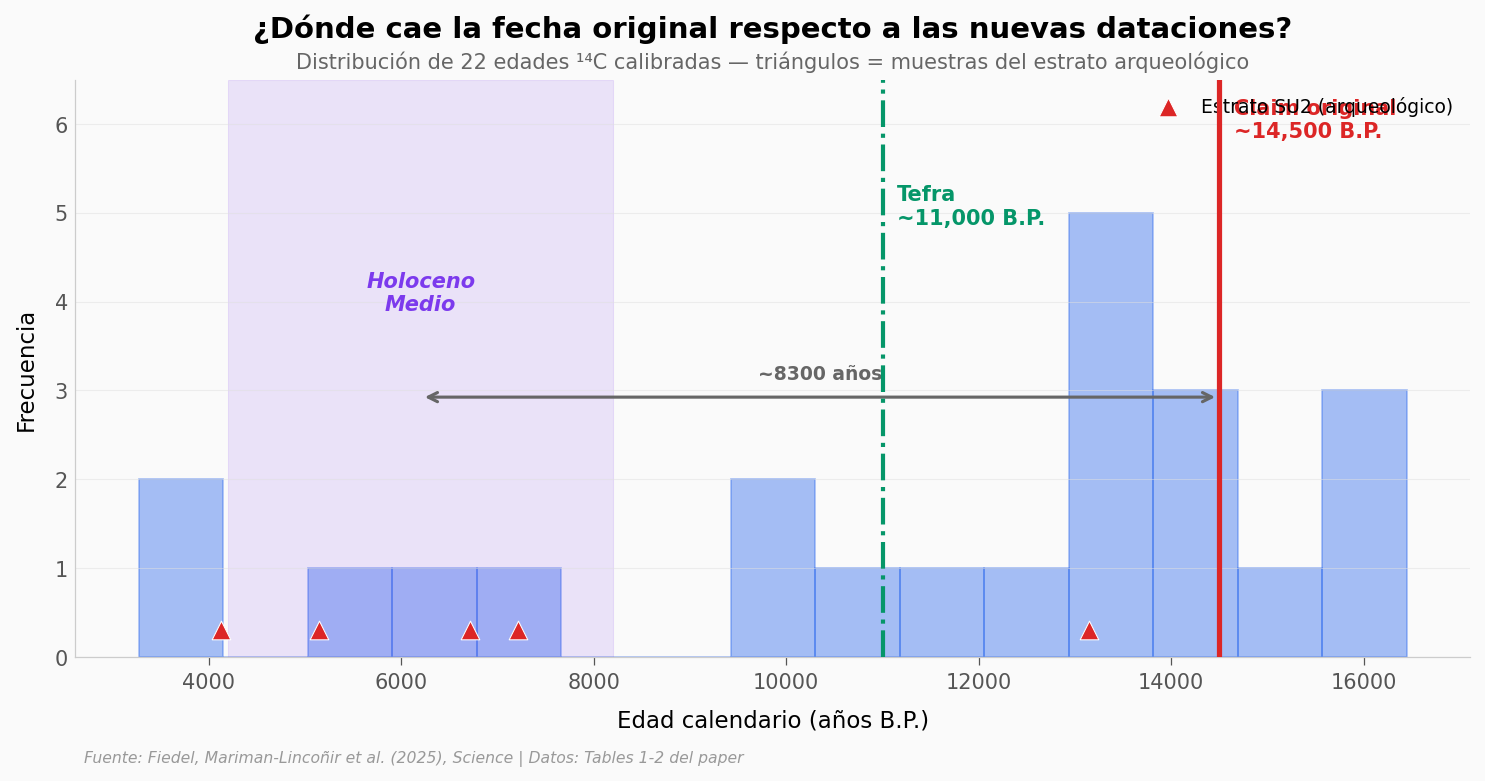

In [5]:
# ── Histograma: distribución de edades vs claims ─────────────
fig, ax = plt.subplots(figsize=(12, 5))

# Todas las edades C14 calibradas
cal_ages = c14.cal_age_median_bp.dropna().values

n_hist, bins, patches = ax.hist(cal_ages, bins=15, color=COLOR_DATOS, alpha=0.4,
                                edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n_hist.max() * 1.3

# Claim original
ax.axvline(x=FECHA_ORIGINAL, color=COLOR_ALERTA, linewidth=2.5, zorder=6)
ax.text(FECHA_ORIGINAL + 150, y_max * 0.9, f'Claim original\n~{FECHA_ORIGINAL:,} B.P.',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold')

# Tefra
ax.axvline(x=TEFRA_FECHA, color=COLOR_TEFRA, linewidth=2, linestyle='-.', zorder=6)
ax.text(TEFRA_FECHA + 150, y_max * 0.75, f'Tefra\n~{TEFRA_FECHA:,} B.P.',
        fontsize=10, color=COLOR_TEFRA, fontweight='bold')

# Holoceno Medio
ax.axvspan(HOLOCENO_MEDIO[1], HOLOCENO_MEDIO[0], color=COLOR_HOLOCENO, alpha=0.12, zorder=1)
ax.text((HOLOCENO_MEDIO[0] + HOLOCENO_MEDIO[1]) / 2, y_max * 0.6, 'Holoceno\nMedio',
        fontsize=10, color=COLOR_HOLOCENO, ha='center', fontstyle='italic', fontweight='bold')

# Flecha: diferencia entre claim original y Holoceno Medio
hol_mid = (HOLOCENO_MEDIO[0] + HOLOCENO_MEDIO[1]) / 2
ax.annotate('', xy=(hol_mid, y_max * 0.45), xytext=(FECHA_ORIGINAL, y_max * 0.45),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff_years = FECHA_ORIGINAL - hol_mid
ax.text((hol_mid + FECHA_ORIGINAL) / 2, y_max * 0.48, f'~{diff_years:.0f} años',
        fontsize=9, color='#666666', ha='center', fontweight='bold')

# Marcar dataciones SU2
su2_ages = c14[c14.stratum == 'SU2'].cal_age_median_bp.dropna().values
ax.scatter(su2_ages, [0.3] * len(su2_ages), marker='^', color=COLOR_ALERTA, s=80,
           edgecolors='white', linewidths=0.5, zorder=7, label='Estrato SU2 (arqueológico)')

ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.set_xlabel('Edad calendario (años B.P.)', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_ylim(0, y_max)
ax.set_title('¿Dónde cae la fecha original respecto a las nuevas dataciones?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'Distribución de {len(cal_ages)} edades ¹⁴C calibradas — triángulos = muestras del estrato arqueológico',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_edades.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|----------|
| Monte Verde II no tiene 14,500 años | ⚠️ | Las nuevas dataciones y la tefra apuntan a una edad mucho más reciente. El estrato SU2 tiene 3/5 fechas en el Holoceno Medio. Pero es una investigación que contradice décadas de consenso — se necesita más trabajo de campo |
| La tefra de ~11,000 B.P. está debajo de la capa arqueológica | ✅ | Dato estratigráfico directo. Si la tefra es más antigua y está debajo, la capa de arriba es más joven. n=5 dataciones en SU1c confirman la posición |
| Las dataciones de luminiscencia apoyan las de radiocarbono | ⚠️ | Ambos métodos cubren rangos similares, pero las muestras de luminiscencia no son del mismo estrato exacto que las de ¹⁴C. n=6, con alta dispersión (2.8-23.4 ka) |
| Los humanos llegaron más recientemente a Sudamérica | ⚠️ | El paper sugiere esto como implicación, pero Monte Verde es solo un sitio. Otros sitios pre-Clovis (Pedra Furada, White Sands) no fueron re-evaluados aquí |

> **Limitaciones:** (1) Solo 23 dataciones ¹⁴C y 6 de luminiscencia — muestreo limitado. (2) Una fecha de SU2 (13,150 B.P.) es mucho más antigua que las otras 4 del mismo estrato — interpretada como material retrabajado, pero no se puede descartar contaminación en las fechas más jóvenes. (3) El paper usa "argue" y "suggest" — los propios autores reconocen que esta es una hipótesis, no una conclusión definitiva. (4) La respuesta de los excavadores originales (Dillehay et al.) aún no se ha publicado.

## Ahora tú

Tres preguntas para explorar:

1. **¿Y si la tefra fuera más antigua?** Cambia `TEFRA_FECHA` a 13,000 B.P. — ¿eso cambiaría la conclusión? ¿Cuántas dataciones de SU2 quedarían por encima?

2. **¿Qué material es más confiable?** El estrato SU2 tiene madera, turba y carbón. ¿Las fechas varían según el material? Filtra `c14[c14.stratum == 'SU2']` por `material`.

3. **¿Qué tan dispersas son las dataciones por estrato?** Calcula la desviación estándar de las edades calibradas por estrato. ¿SU2 es el más disperso? ¿Eso sugiere mezcla de materiales?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué tan disperso es cada estrato? Un estrato con alta dispersión
# podría tener material de diferentes épocas mezclado.

for stratum in ['SU1a', 'SU1b', 'SU1c', 'SU2', 'SU1d']:
    sub = c14[c14.stratum == stratum].cal_age_median_bp.dropna()
    if len(sub) >= 2:
        print(f'{stratum}: media = {sub.mean():,.0f} B.P., '
              f'σ = {sub.std(ddof=1):,.0f} años, '
              f'rango = {sub.max() - sub.min():,.0f} años, '
              f'n = {len(sub)}')
    else:
        print(f'{stratum}: n = {len(sub)} (insuficiente para σ)')

SU1a: media = 16,337 B.P., σ = 147 años, rango = 280 años, n = 3
SU1b: media = 13,882 B.P., σ = 463 años, rango = 1,280 años, n = 8
SU1c: media = 10,954 B.P., σ = 1,206 años, rango = 3,050 años, n = 5
SU2: media = 7,268 B.P., σ = 3,510 años, rango = 9,020 años, n = 5
SU1d: n = 1 (insuficiente para σ)


---

**Paper:** Fiedel, Mariman-Lincoñir et al. (2025) — *Monte Verde is not an early archaeological site.* Science.  
**DOI:** [10.1126/science.adw9217](https://doi.org/10.1126/science.adw9217)  
**Datos:** Tables 1 y 2 del paper (23 dataciones ¹⁴C + 6 de luminiscencia)  
**Licencia:** Los datos del paper se usan bajo fair use académico para reproducibilidad. Código del notebook: [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/).

*[Ciencia a Mordiscos](https://youtube.com/@CienciaaMordiscos) · [El Lab](https://lab.cienciaamordiscos.com)*